In [1]:
import coflandscaper as cl

/Users/gregorlauter/Documents/PhD/2d-cof-mapper/COF-Landscaper/.venv/lib/python3.12/site-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))


cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.


## Before you run this notebook (required)

- Place exactly one node XYZ in 0_node/ and one linker XYZ in 0_linker/.
- At the connection points, insert a dummy atom: **He** if node and linker are connected by a single bond and **Se** f node and linker are connected by a double bond .
- If your COF contains Se atoms, this workflow will not work with double bonds. Please report this to the GitHub maintainers.
- Choose a unique `COF_NAME`; all outputs will be saved under a folder named after it.

## Settings & options (what you can choose)

- `TOPOLOGY`: "hcb" or "sql".
- `BOND_TYPE`: "single" or "double" (must match your dummy atom choice).
- `COF_NAME`: "example-cof".
- `MODE`: choose what stacking modes to investigate: "incl" (inclined), "serr" (serrated), or "both".

In [2]:
TOPOLOGY = "hcb"
BOND_TYPE = "single" 
COF_NAME = "cof-1"
MODE = 'both'

## Optional settings

- `MACE_HEAD`: choose the MACE head for the mace-mh-1 model (default: "omat_pbe").
  - Model info: https://huggingface.co/mace-foundations/mace-mh-1
  - Recommended heads: "omat_pbe", "omol", "spice_wB97M", "matpes_r2scan".
- Set `MACE_HEAD` in the next cell to override the default.

In [ ]:
MACE_HEAD = "omat_pbe"

## Build single‑layer COF + pre‑optimize

Creates the single‑layer COF and then pre‑optimizes it with MACE.

Defaults (advanced cells below):
- `MacePreopt`: `fmax=0.01`, `dtype="float64"`, `head="omat_pbe"`, `device="cpu"`, `fix_z=True`, `dispersion=False`.

Options (advanced cells below):
- `fmax`: force convergence threshold (lower = tighter, slower).
- `dtype`: numerical precision; use `"float64"` (more accurate, slower) or `"float32"` (faster, less accurate).
- `head`: MACE head to use (e.g., `"omat_pbe"`, `"omol"`, `"spice_wB97M"`, `"matpes_r2scan"`).
- `device`: compute device, e.g. `"cpu"` or `"cuda"` (if available).
- `fix_z`: if `True`, freezes atomic motion along $z$ so the layer stays flat. This can prevent twisting in a free single layer, which can otherwise lead to unphysical overlaps and unstable downstream structure generation. With `fix_z=True`, only in‑plane positions relax while $z$ remains as in the initial pormake structure.

In [ ]:
# Defaults
builder = cl.BuildCOF2D()
builder.build(topo=TOPOLOGY, bond_type=BOND_TYPE, cof_name=COF_NAME)

In [ ]:
# Defaults
preopt = cl.MacePreopt()
preopt.run(COF_NAME)

In [ ]:
# Configurable (all options)
preopt = cl.MacePreopt(
    fmax=0.01,
    dtype="float64",
    head=MACE_HEAD,
    device="cpu",
    fix_z=True,
 )
preopt.run(COF_NAME)

## Create ILD×ILS matrix

Generate stacking variants by changing interlayer distance (ILD, along $z$) and interlayer slipping (ILS, in‑plane).

- Serrated: build a bilayer and shift the top layer back and forth around the AB shift.
- Inclined: tilt the $c$ vector to apply a continuous in‑plane shift in one direction.
- Default slip length/angle correspond to AB stacking and are auto‑computed (use `print_shift` to show them).

Outputs go to `COF_NAME`/2_{`COF_NAME`}_matrix/serr or /incl depending on `MODE`. These structures are used for single‑point energy evaluation and landscape plots.

Advanced options (configurable cell):
- ILD range: `ild_start`, `ild_end`, `ild_step`.
- ILS range: `shift_length_start`, `shift_length_end`, `shift_length_step`.
- Direction: `shift_angle` (degrees).
- `print_shift` to display the auto‑computed AB shift.

In [ ]:
# Defaults
matrix = cl.CreateMatrix()
matrix.run(cof_name=COF_NAME, topo=TOPOLOGY, mode=MODE)

In [ ]:
# Configurable (all options)
matrix = cl.CreateMatrix(
    ild_start=3.0,
    ild_end=4.5,
    ild_step=0.1,
    shift_length_start=0.0,
    shift_length_end=None,
    shift_length_step=1.0,
    shift_angle=None,
    print_shift=True,
 )
matrix.run(cof_name=COF_NAME, topo=TOPOLOGY, mode=MODE)

## MACE single‑point energies (no optimization)

Compute energies for each ILD/ILS structure to build the energy landscape. No geometry optimization is performed.

Defaults:
- Uses the MACE head set in `MACE_HEAD` ("omat_pbe" by default).
- Dispersion defaults by head (`omat_pbe`/`matpes_r2scan` = on; `omol`/`spice` = off).
- Results are saved in `COF_NAME`/3_{`COF_NAME`}_landscape as {`COF_NAME`}_energies_{serr|incl}_mace-mh-1-{`MACE_HEAD`}.csv.

Options:
- `device`, `dtype`, `head`, `dispersion` (manual override), `output_csv_dir`.

From here on, you can also choose a DFT route to compute these energies instead of MACE (not shown here).

In [3]:
# Defaults
sp = cl.MaceSP()
sp.run_mode(cof_name=COF_NAME, mode=MODE)

Using medium MPA-0 model as default MACE-MP model, to use previous (before 3.10) default model please specify 'medium' as model argument
Using Materials Project MACE for MACECalculator with /Users/gregorlauter/.cache/mace/macempa0mediummodel
Using float64 for MACECalculator, which is slower but more accurate. Recommended for geometry optimization.
Using head omat_pbe out of ['default']
Using TorchDFTD3Calculator for D3 dispersion corrections


/Users/gregorlauter/Documents/PhD/2d-cof-mapper/COF-Landscaper/.venv/lib/python3.12/site-packages/torch_dftd/torch_dftd3_calculator.py:98: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:256.)
  cell: Optional[Tensor] = torch.tensor(


[single-point] 25/160 done | ok=25 | failed=0
[single-point] 50/160 done | ok=50 | failed=0
[single-point] 75/160 done | ok=75 | failed=0
[single-point] 100/160 done | ok=100 | failed=0
[single-point] 125/160 done | ok=125 | failed=0
[single-point] 150/160 done | ok=150 | failed=0
[single-point] 160/160 done | ok=160 | failed=0
Using medium MPA-0 model as default MACE-MP model, to use previous (before 3.10) default model please specify 'medium' as model argument
Using Materials Project MACE for MACECalculator with /Users/gregorlauter/.cache/mace/macempa0mediummodel
Using float64 for MACECalculator, which is slower but more accurate. Recommended for geometry optimization.
Using head omat_pbe out of ['default']
Using TorchDFTD3Calculator for D3 dispersion corrections
[single-point] 25/160 done | ok=25 | failed=0
[single-point] 50/160 done | ok=50 | failed=0
[single-point] 75/160 done | ok=75 | failed=0
[single-point] 100/160 done | ok=100 | failed=0
[single-point] 125/160 done | ok=125 |

[PosixPath('cof-1/3_cof-1_landscape/cof-1_energies_serr_mace-mh-1-omat_pbe.csv'),
 PosixPath('cof-1/3_cof-1_landscape/cof-1_energies_incl_mace-mh-1-omat_pbe.csv')]

In [ ]:
# Configurable (all options)
sp = cl.MaceSP()
sp.run_mode(
    cof_name=COF_NAME,
    mode=MODE,
    device="cpu",
    dtype="float64",
    head=MACE_HEAD,
    dispersion=None,
 )

## Landscape + select structures

- Landscape plots are written to `COF_NAME`/3_{`COF_NAME`}_landscape.
- Selection identifies local minima on the simplified PES; the corresponding structures are then used for downstream optimization (MACE here or DFT in seperate notebook).
- Selected CIFs are written to `COF_NAME`/4_{`COF_NAME`}_final_structures/{serr|incl}/input.
- Default behavior: include the global minimum for each mode (serr/incl). You may optionally add extra (ILD, ILS) points in Å below.

<Figure size 1000x600 with 0 Axes>

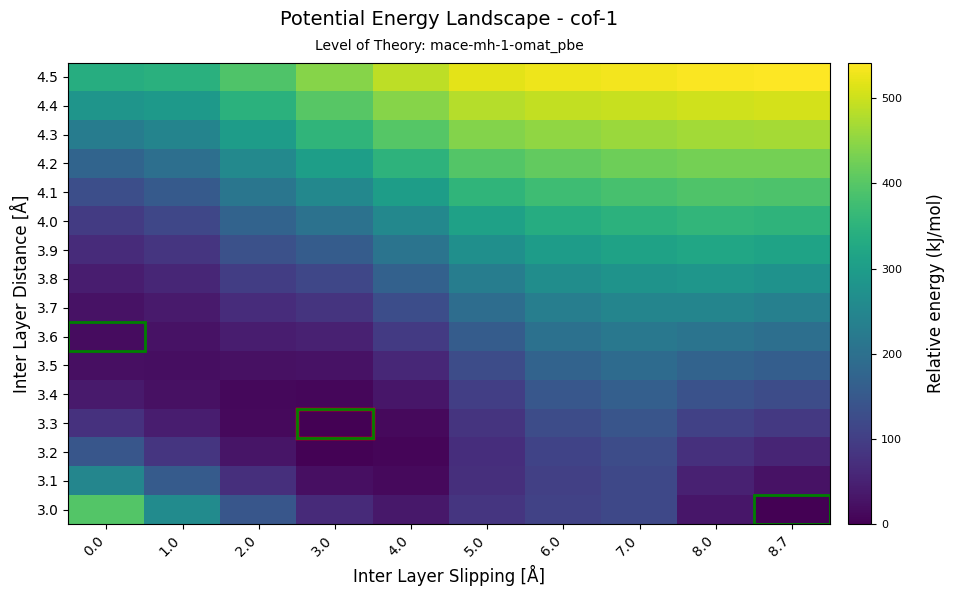

Saved: cof-1/3_cof-1_landscape/pes_cof-1_serr_heatmap_mace-mh-1-omat_pbe.png


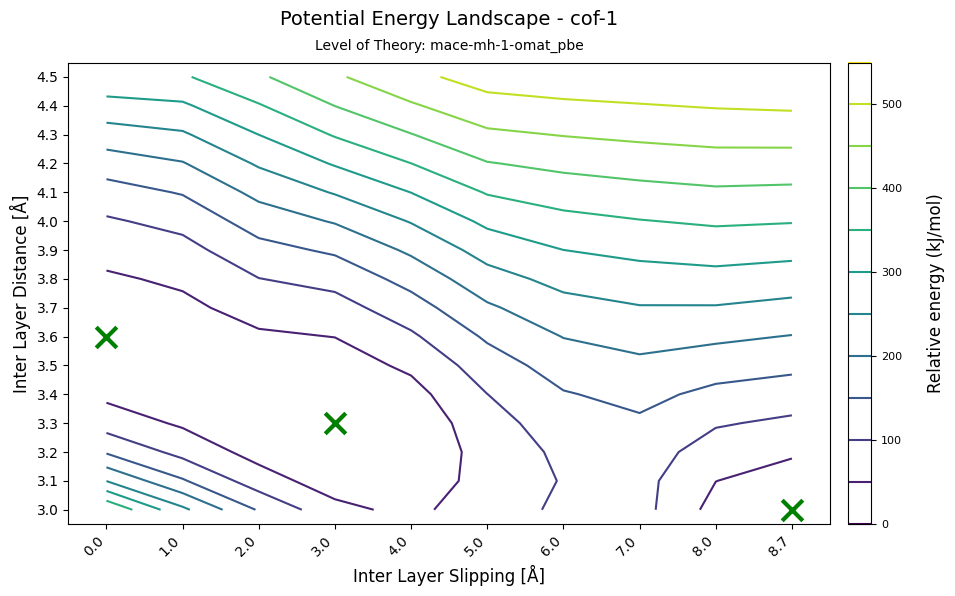

Saved: cof-1/3_cof-1_landscape/pes_cof-1_serr_isolines_mace-mh-1-omat_pbe.png


<Figure size 1000x600 with 0 Axes>

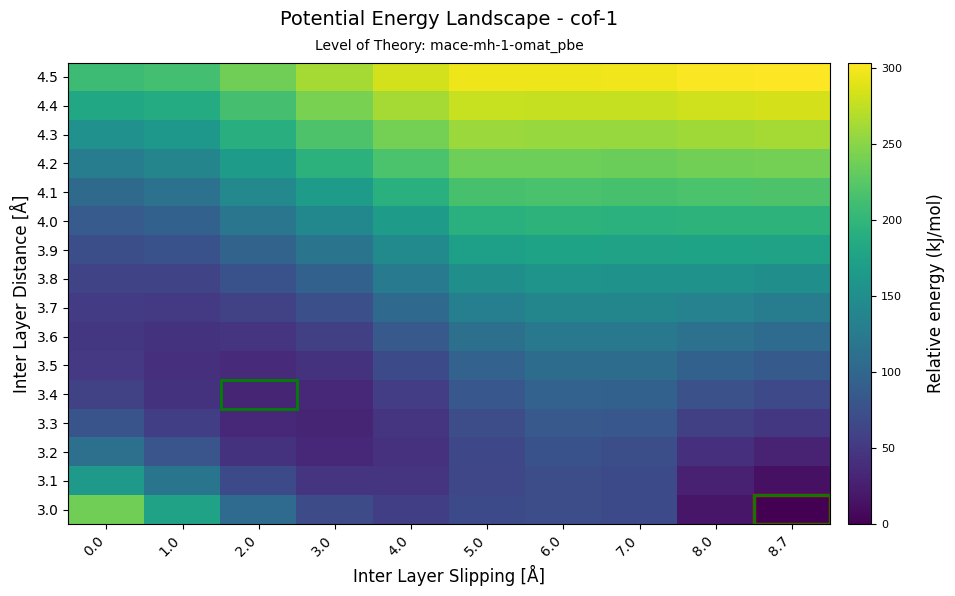

Saved: cof-1/3_cof-1_landscape/pes_cof-1_incl_heatmap_mace-mh-1-omat_pbe.png


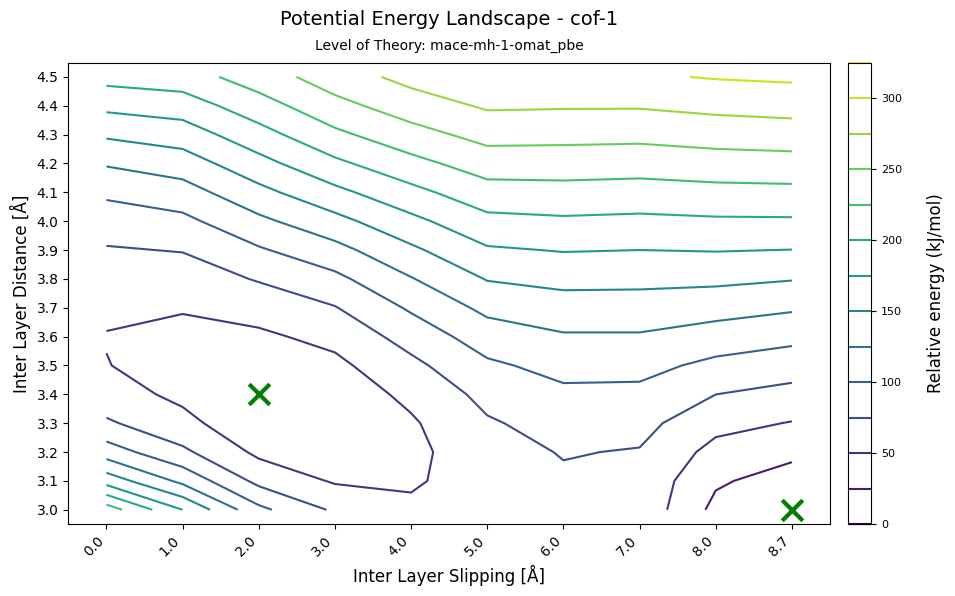

Saved: cof-1/3_cof-1_landscape/pes_cof-1_incl_isolines_mace-mh-1-omat_pbe.png


[PosixPath('cof-1/3_cof-1_landscape'), PosixPath('cof-1/3_cof-1_landscape')]

In [4]:
landscape = cl.Landscape()
landscape.run_mode(cof_name=COF_NAME, mode=MODE)

In [5]:
# Defaults (auto-select local minima per mode)
selector = cl.SelectCofs()
selector.run_mode(cof_name=COF_NAME, mode=MODE)


Selected ILD/ILS pairs (Serrated):
 ILD (Å)  ILS (Å)
     3.0      8.7
     3.3      3.0
     3.6      0.0

Selected ILD/ILS pairs (Inclined):
 ILD (Å)  ILS (Å)
     3.0      8.7
     3.4      2.0


In [ ]:
# Optional: add extra selections (ILD, ILS) in Å
EXTRA_SERR = []
EXTRA_INCL = [(3.0, 8.7)]
selector = cl.SelectCofs()
selector.run_mode(
    cof_name=COF_NAME,
    mode=MODE,
    selections_serr=EXTRA_SERR,
    selections_incl=EXTRA_INCL,
    include_minima=True,
 )

In [ ]:
cl.opt_mace(input_folder=f"{COF_NAME}/4_{COF_NAME}_final_structures/serr/input", output_folder=f"{COF_NAME}/cofs_opt_serr", fmax=0.01, head=MACE_HEAD, fix_z=False, dispersion=True)
cl.CalcIlsDl().run(input_folder=f"{COF_NAME}/cofs_opt_serr")
cl.CheckIld().run(input_folder=f"{COF_NAME}/cofs_opt_serr")

In [ ]:
cl.opt_mace(input_folder=f"{COF_NAME}/4_{COF_NAME}_final_structures/incl/input", output_folder=f"{COF_NAME}/cofs_opt_incl", fmax=0.01, head=MACE_HEAD, fix_z=False, dispersion=True)
cl.CalcIlsSl().run(input_folder=f"{COF_NAME}/cofs_opt_incl")

In [ ]:
# print each filename and visualize all structures in folder
cl.VisualizeCOF().view(f"{COF_NAME}/cofs_opt_serr")

In [ ]:
cl.Supercell().run(input_folder=f"{COF_NAME}/cofs_opt_serr", output_folder=f"{COF_NAME}/cofs_supercell", supercell_size=(2, 2, 1))
cl.VisualizeCOF().view(f"{COF_NAME}/cofs_supercell")

ADDITIONAL FEATURES/HELPERS OUTSIDE THE WORKFLOW

In [ ]:
# cl.SetVacuum().run(input_folder="cofs_preopt", output_folder="cofs_vac", vacuum_top=10.0)
# cl.CheckIld().run("cofs_vac")
# cl.CenterZ().run(input_folder= "cofs_vac", output_folder="cofs_center")
# cl.RemoveLayer().run(input_folder= "cofs_serr", output_folder="cofs_rm", remove_z=0.75, remove_tol=0.1, mode="frac")
# cl.CheckIld().run("cofs_rm")
# cl.Supercell().run(input_folder="cofs_center", output_folder="cofs_supercell", supercell_size=(2, 2, 2))